In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, confusion_matrix, accuracy_score

from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

from skopt import BayesSearchCV
from sklearn.model_selection import StratifiedKFold
from IPython.display import display, Latex

In [2]:
df = pd.read_csv('database-am-6.csv')  # Substitua pelo caminho correto se necessário
df = df.drop(columns=['Unnamed: 0'])  # Remover índice salvo no CSV

X = df.drop('Q092', axis=1)
y = df['Q092']

X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [3]:
def avaliar_modelo(modelo, X_treino, y_treino, X_teste, y_teste, nome="Modelo"):
    modelo.fit(X_treino, y_treino)
    y_pred = modelo.predict(X_teste)

    report_dict = classification_report(y_teste, y_pred, output_dict=True)
    df = pd.DataFrame(report_dict).transpose()
    df = df.round(2)
    df.rename(index={
    "0.0": "DN",
    "1.0": "DP"
    }, inplace=True)


        # Salvar a tabela como .tex (Latex) em arquivo externo
    df_latex = df.copy()
    df_latex.rename(index={"0.0": "DN", "1.0": "DP"}, inplace=True)  # Renomeia as classes se necessário
    df_latex = df_latex.loc[["DN", "DP", "macro avg", "weighted avg"]]  # Reordena se quiser
    
    # Exporta para um arquivo .tex
    df_latex.to_latex(
        buf=f"tabela_{nome.replace(' ', '_').lower()}.tex",
        float_format="%.2f",
        index=True
    )

    fig, ax = plt.subplots(figsize=(6, 2.5))
    ax.axis('off')
    tbl = ax.table(cellText=df.values, colLabels=df.columns, rowLabels=df.index, loc='center', cellLoc='center')
    tbl.scale(1.2, 1.5)
    plt.title(f"Resultados - {nome}", fontsize=12)
    plt.tight_layout()
    plt.show()


    cm = confusion_matrix(y_teste, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"Matriz de Confusão - {nome}")
    plt.xlabel("Previsto")
    plt.ylabel("Real")
    plt.tight_layout()
    plt.show()

    if hasattr(modelo, "feature_importances_"):
        importancias = pd.Series(modelo.feature_importances_, index=X_treino.columns)
        top_importantes = importancias.sort_values(ascending=False).head(20)
        
        plt.figure(figsize=(8, 6))
        top_importantes.plot(kind="barh")
        plt.title(f"20 Variáveis Mais Relevantes - {nome}")
        plt.xlabel("Importância")
        plt.gca().invert_yaxis()
        plt.tight_layout()
        plt.show()
        
    return modelo, y_pred


In [4]:
def extrair_metricas(y_verdadeiro, y_predito, nome="Modelo"):
    report = classification_report(y_verdadeiro, y_predito, output_dict=True)
    return {
        "Modelo": nome,
        "Accuracy": accuracy_score(y_verdadeiro, y_predito),
        "0_Precision": report["0.0"]["precision"],
        "0_Recall": report["0.0"]["recall"],
        "0_F1": report["0.0"]["f1-score"],
        "1_Precision": report["1.0"]["precision"],
        "1_Recall": report["1.0"]["recall"],
        "1_F1": report["1.0"]["f1-score"],
        "F1_Macro": report["macro avg"]["f1-score"]
    }

## Treinamento com dados originais

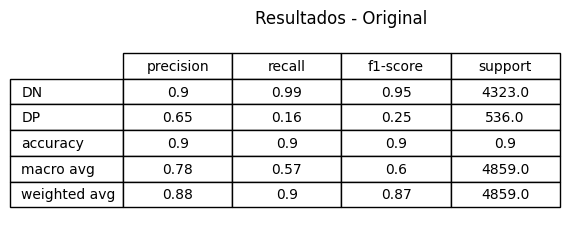

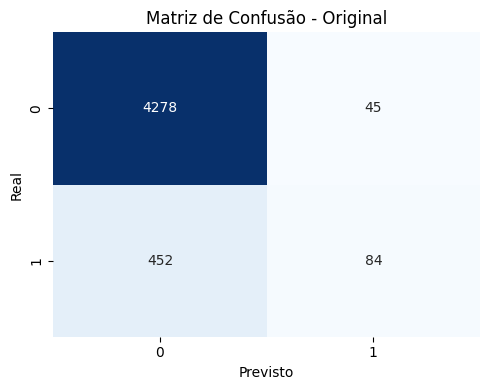

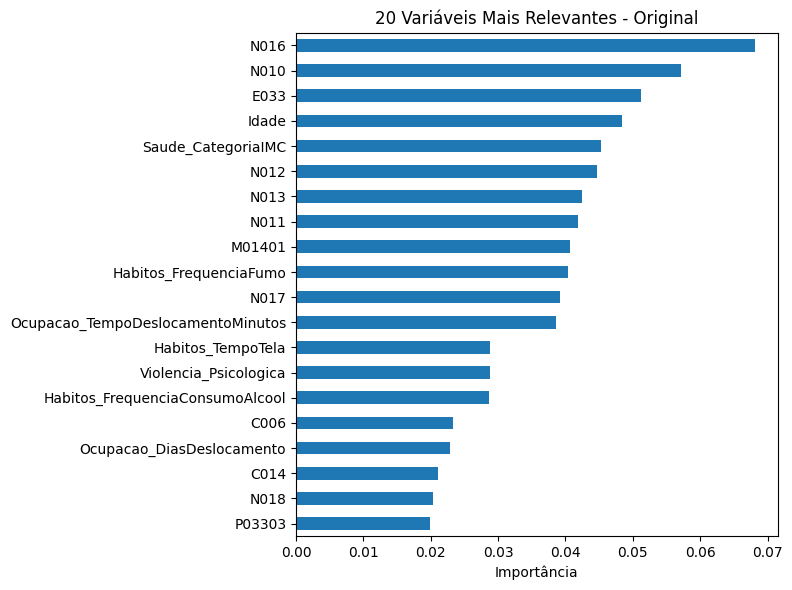

In [5]:
modelo_original = RandomForestClassifier(random_state=42)
f1_original = avaliar_modelo(modelo_original, X_treino, y_treino, X_teste, y_teste, "Original")


## Balanceamento com under e over sampling

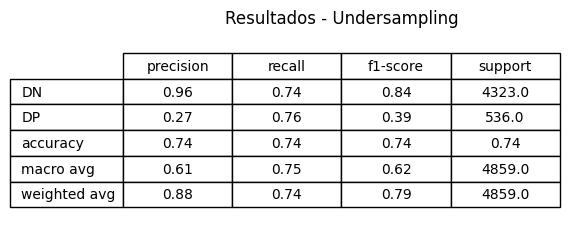

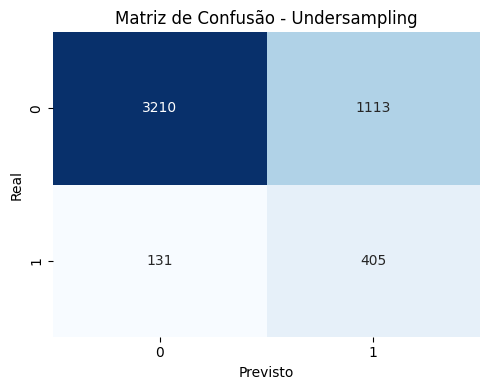

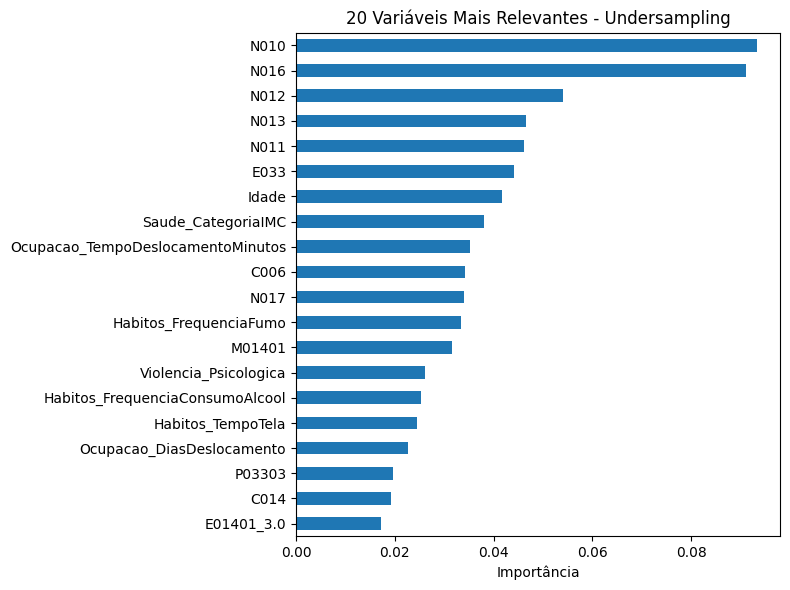

In [6]:
rus = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus.fit_resample(X_treino, y_treino)
modelo_under = RandomForestClassifier(random_state=42)
f1_under = avaliar_modelo(modelo_under, X_rus, y_rus, X_teste, y_teste, "Undersampling")


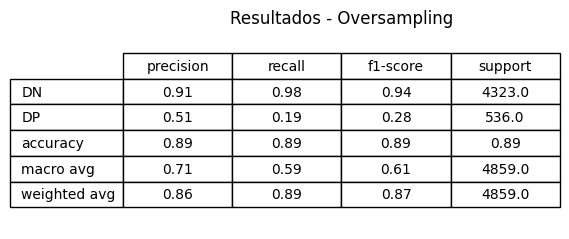

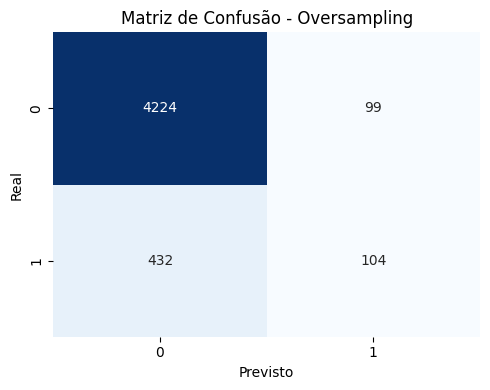

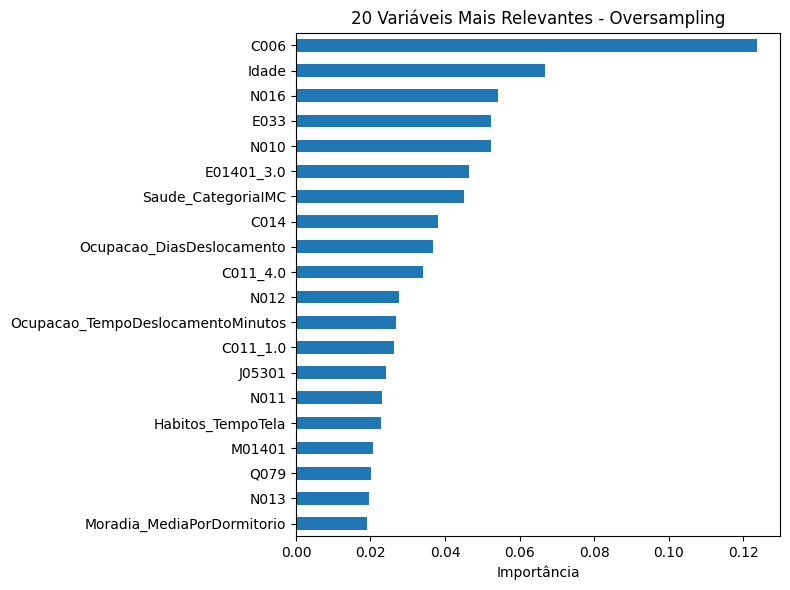

In [7]:
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_treino, y_treino)
modelo_over = RandomForestClassifier(random_state=42)
f1_over = avaliar_modelo(modelo_over, X_smote, y_smote, X_teste, y_teste, "Oversampling")


## Otimização com BayesSearchCV

In [8]:
param_space = {
    'n_estimators': (100, 1000),
    'max_depth': (5, 50),
    'min_samples_split': (2, 20),
    'min_samples_leaf': (1, 10),
    'max_features': ['sqrt', 'log2', None]
}


In [9]:
def otimizar_e_avaliar(X_tr, y_tr, X_te, y_te, nome):
    bayes = BayesSearchCV(
        estimator=RandomForestClassifier(random_state=42),
        search_spaces=param_space,
        cv=StratifiedKFold(n_splits=3),
        n_iter=15,
        scoring='f1_macro',
        n_jobs=-1,
        random_state=42
    )
    bayes.fit(X_tr, y_tr)
    return avaliar_modelo(bayes.best_estimator_, X_tr, y_tr, X_te, y_te, nome + " Otimizado")


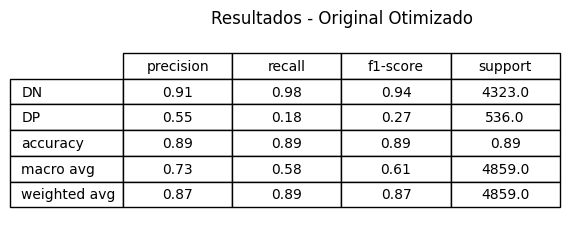

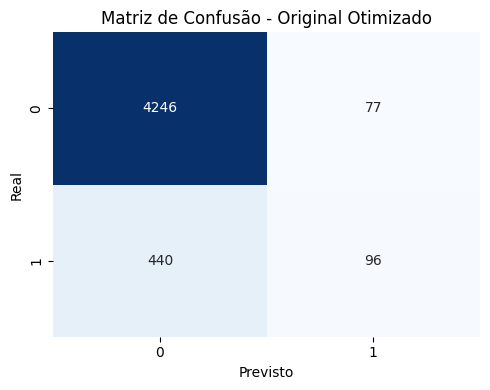

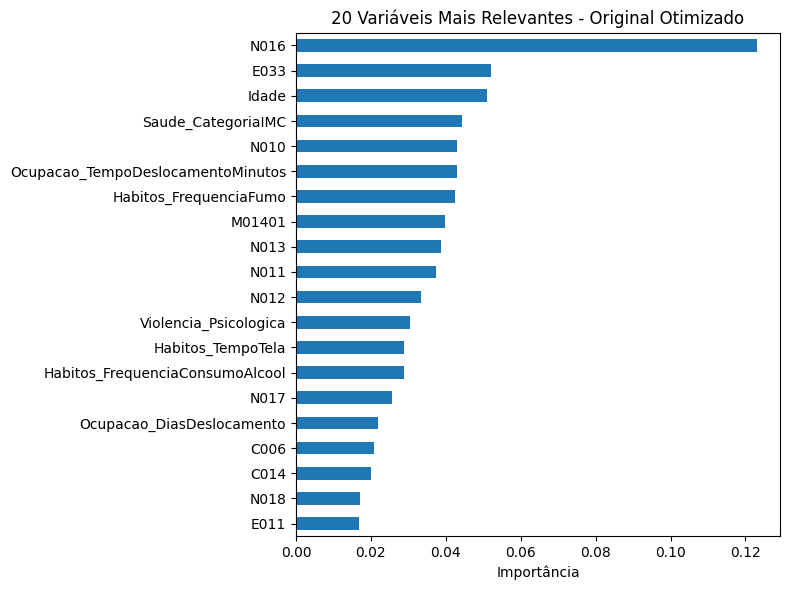

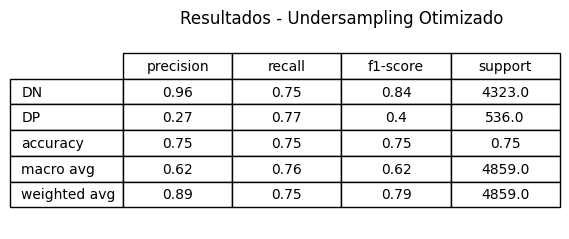

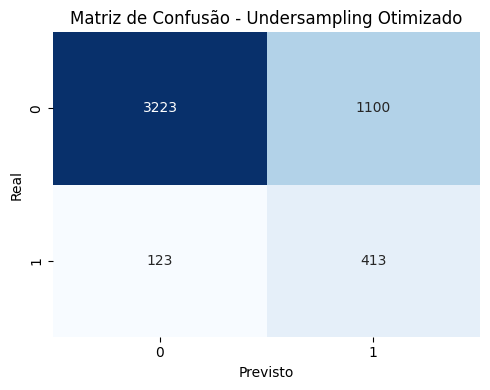

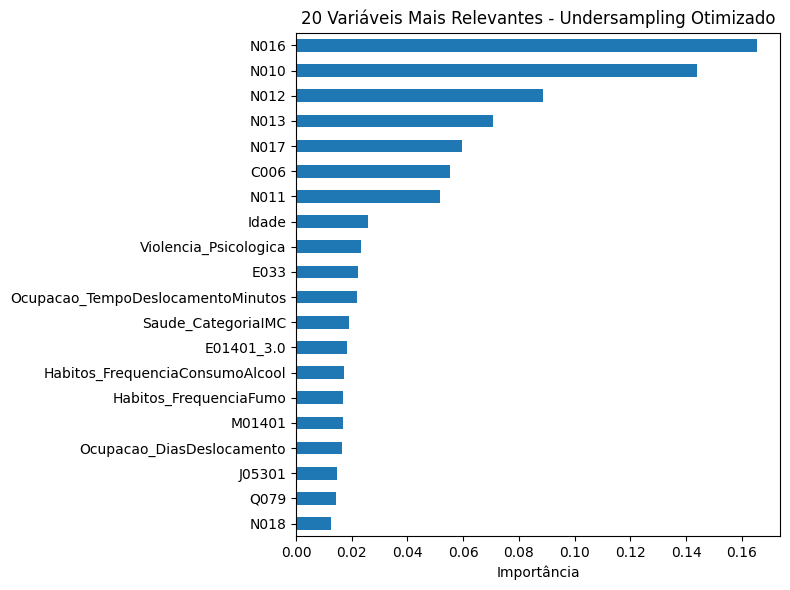

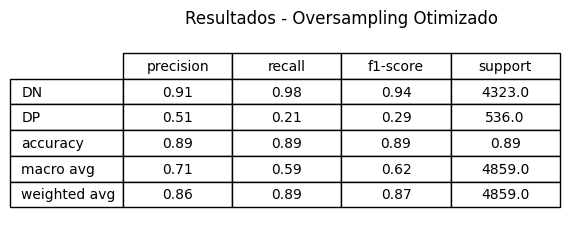

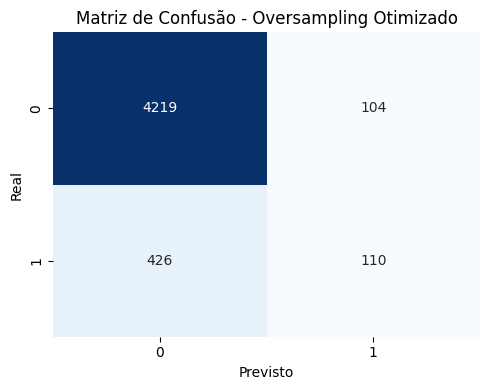

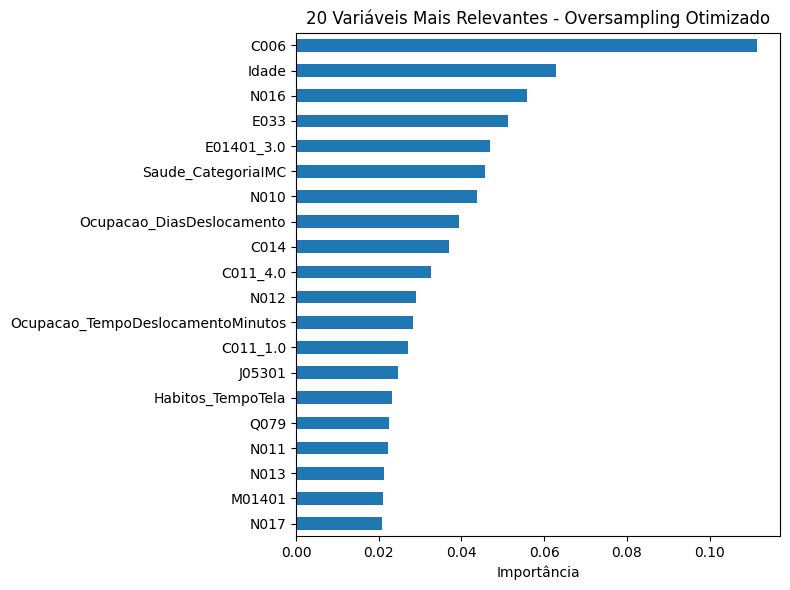

In [10]:
original_opt, y_pred_opt = otimizar_e_avaliar(X_treino, y_treino, X_teste, y_teste, "Original")
under_opt, y_pred_opt = otimizar_e_avaliar(X_rus, y_rus, X_teste, y_teste, "Undersampling")
over_opt, y_pred_opt = otimizar_e_avaliar(X_smote, y_smote, X_teste, y_teste, "Oversampling")


## Comparação final

In [12]:
metricas = []

metricas.append(extrair_metricas(y_teste, modelo_original.predict(X_teste), "Original"))
metricas.append(extrair_metricas(y_teste, modelo_under.predict(X_teste), "Undersampling"))
metricas.append(extrair_metricas(y_teste, modelo_over.predict(X_teste), "Oversampling"))
metricas.append(extrair_metricas(y_teste, original_opt.predict(X_teste), "Original Otimizado"))
metricas.append(extrair_metricas(y_teste, under_opt.predict(X_teste), "Undersampling Otimizado"))
metricas.append(extrair_metricas(y_teste, over_opt.predict(X_teste), "Oversampling Otimizado"))

df_resultados = pd.DataFrame(metricas).round(2)
display(df_resultados)
df_resultados.to_latex("tabela_comparativa_modelos_2.tex", index=False, float_format="%.2f")

,Modelo,Accuracy,0_Precision,0_Recall,0_F1,1_Precision,1_Recall,1_F1,F1_Macro
0,Original,0.90,0.90,0.99,0.95,0.65,0.16,0.25,0.60
1,Undersampling,0.74,0.96,0.74,0.84,0.27,0.76,0.39,0.62
2,Oversampling,0.89,0.91,0.98,0.94,0.51,0.19,0.28,0.61
3,Original Otimizado,0.89,0.91,0.98,0.94,0.55,0.18,0.27,0.61
4,Undersampling Otimizado,0.75,0.96,0.75,0.84,0.27,0.77,0.40,0.62
5,Oversampling Otimizado,0.89,0.91,0.98,0.94,0.51,0.21,0.29,0.62
